<a href="https://colab.research.google.com/github/sukumar-kollabathula/Apex-/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn openpyxl

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
from google.colab import files

uploaded = files.upload()

In [6]:
import zipfile
import os


zip_file_path = '/content/archive.zip'

extract_path = '/content/extracted_data'
os.makedirs(extract_path, exist_ok=True)


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


df = pd.read_csv(os.path.join(extract_path, 'Customer_Data.csv'))

df.info()

df.drop_duplicates(inplace=True)

df.isnull().sum()

df.fillna(0, inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   cust_id                           8950 non-null   object 
 1   balance                           8950 non-null   float64
 2   balance_frequency                 8950 non-null   float64
 3   purchases                         8950 non-null   float64
 4   oneoff_purchases                  8950 non-null   float64
 5   installments_purchases            8950 non-null   float64
 6   cash_advance                      8950 non-null   float64
 7   purchases_frequency               8950 non-null   float64
 8   oneoff_purchases_frequency        8950 non-null   float64
 9   purchases_installments_frequency  8950 non-null   float64
 10  cash_advance_frequency            8950 non-null   float64
 11  cash_advance_trx                  8950 non-null   int64  
 12  purcha

In [7]:
total_revenue = df['purchases'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 8978683.26


In [8]:
total_orders = df['cust_id'].nunique()

print("Total Unique Customers (using cust_id):", total_orders)

Total Unique Customers (using cust_id): 8950


In [9]:
aov = total_revenue / total_orders

print("Average Order Value:", round(aov,2))

Average Order Value: 1003.2


In [10]:
customers = df['cust_id'].nunique()

print("Customers:", customers)

Customers: 8950


In [11]:
rpc = total_revenue / customers

print("Revenue Per Customer:", round(rpc,2))

Revenue Per Customer: 1003.2


In [12]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=total_revenue,
    title={"text":"Total Revenue"}
))

fig.show()

In [13]:
revenue_by_tenure = df.groupby('tenure')['purchases'].sum().reset_index()

revenue_by_tenure.columns = ['Tenure_Months', 'Total_Purchases']

fig = px.line(
    revenue_by_tenure,
    x='Tenure_Months',
    y='Total_Purchases',
    title='Total Purchases by Customer Tenure (Months)'
)

fig.show()

In [14]:
df['Age_Cohort_Months'] = df['tenure']

print("Cohorts defined based on customer 'tenure' (Age_Cohort_Months).")

Cohorts defined based on customer 'tenure' (Age_Cohort_Months).


In [15]:
cohort_data = df.groupby('Age_Cohort_Months')['cust_id'].nunique().reset_index()

cohort_data.rename(columns={'cust_id': 'Unique_Customers'}, inplace=True)
print("Unique Customers by Age Cohort (Tenure in Months):")
print(cohort_data)

Unique Customers by Age Cohort (Tenure in Months):
   Age_Cohort_Months  Unique_Customers
0                  6               204
1                  7               190
2                  8               196
3                  9               175
4                 10               236
5                 11               365
6                 12              7584


In [16]:
fig = px.bar(
    cohort_data,
    x='Age_Cohort_Months',
    y='Unique_Customers',
    title='Distribution of Unique Customers by Tenure Cohort',
    labels={
        'Age_Cohort_Months': 'Tenure in Months',
        'Unique_Customers': 'Number of Unique Customers'
    },
    color='Unique_Customers',
    color_continuous_scale=px.colors.sequential.Viridis
)

fig.update_layout(
    xaxis_title='Customer Tenure (Months)',
    yaxis_title='Number of Unique Customers',
    xaxis={'type': 'category'}
)

fig.show()

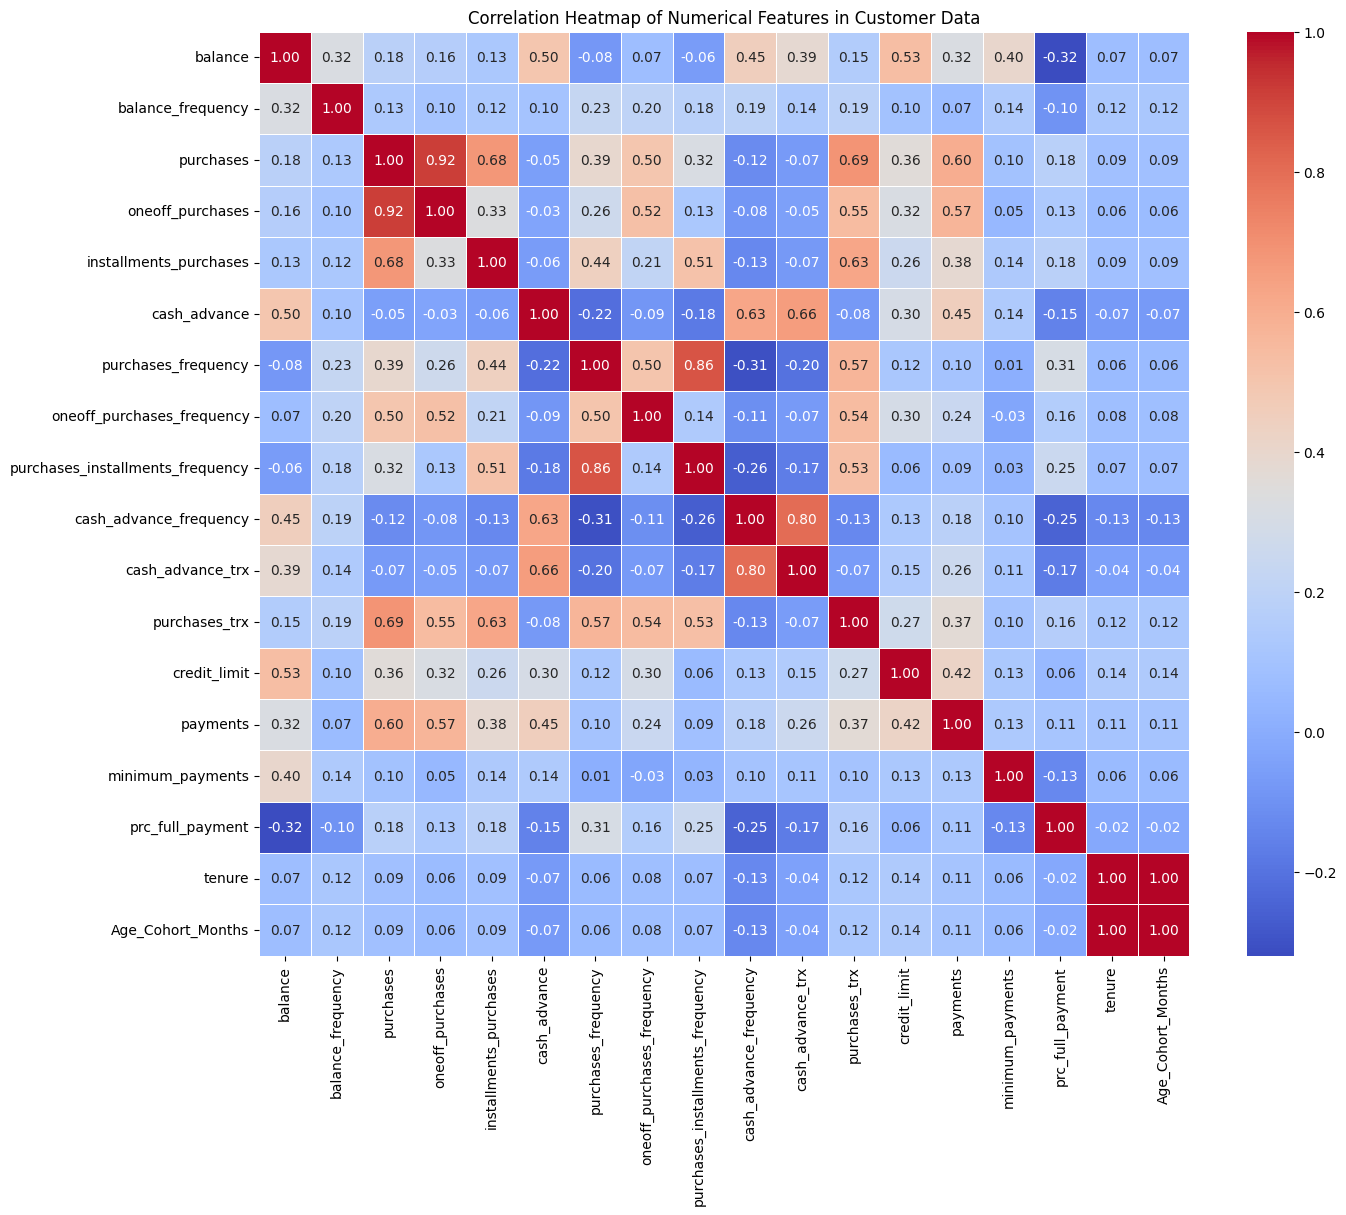

In [17]:
numerical_df = df.select_dtypes(include=np.number)


corr_matrix = numerical_df.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5
)
plt.title('Correlation Heatmap of Numerical Features in Customer Data')
plt.show()

In [18]:
funnel = pd.DataFrame({
    'Stage':['Visitors',
             'Product View',
             'Add To Cart',
             'Checkout',
             'Purchase'],
    'Users':[10000,7000,4000,2500,1800]
})

In [19]:
fig = px.funnel(
    funnel,
    x='Users',
    y='Stage',
    title='Sales Funnel Analysis'
)

fig.show()

In [20]:
rfm_adapted = df.groupby('cust_id').agg(
    Frequency=('purchases_trx', 'sum'),
    Monetary=('purchases', 'sum')
)

print("Adapted RFM-like DataFrame (Frequency and Monetary):")
display(rfm_adapted.head())

Adapted RFM-like DataFrame (Frequency and Monetary):


,Frequency,Monetary
cust_id,,
C10001,2,95.40
C10002,0,0.00
C10003,12,773.17
C10004,1,1499.00
C10005,1,16.00


In [21]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(rfm_adapted)

In [22]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm_adapted['Cluster'] = kmeans.fit_predict(
    scaled_data
)

rfm_adapted.head()

,Frequency,Monetary,Cluster
cust_id,,,
C10001,2,95.40,1
C10002,0,0.00,1
C10003,12,773.17,1
C10004,1,1499.00,1
C10005,1,16.00,1


In [23]:
fig = px.scatter(
    rfm_adapted,
    x='Frequency',
    y='Monetary',
    color='Cluster',
    title='Customer Segments'
)

fig.show()

In [24]:
top_customers_by_purchases = df.groupby(
    'cust_id'
)['purchases'].sum().sort_values(
    ascending=False
).head(10)

print("Top 10 Customers by Total Purchases:")
display(top_customers_by_purchases)

Top 10 Customers by Total Purchases:


,purchases
cust_id,
C10574,49039.57
C10523,41050.40
C11300,40040.71
C11657,38902.71
C14048,35131.16
C10284,32539.78
C11695,31299.35
C10611,27957.68
C13802,27790.42


In [25]:
fig = px.bar(
    top_customers_by_purchases,
    title='Top 10 Customers by Total Purchases'
)

fig.show()

In [26]:
fig = px.histogram(
    df,
    x='purchases',
    nbins=50,
    title='Distribution of Customer Purchases',
    labels={'purchases': 'Total Purchases'}
)

fig.update_layout(xaxis_title='Total Purchases', yaxis_title='Number of Customers')
fig.show()

In [27]:
kpi_report = pd.DataFrame({
    'Metric':[
        'Revenue',
        'Orders',
        'Customers',
        'AOV'
    ],
    'Value':[
        total_revenue,
        total_orders,
        customers,
        aov
    ]
})

kpi_report.to_excel(
    'KPI_Report.xlsx',
    index=False
)

In [28]:
!pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 37.9 MB/s eta 0:00:00
